# Sonitel Industrial — Entrenamiento en Kaggle

**Datasets necesarios (añadir desde el panel derecho):**
- `sonitel-code` → los 16 ficheros .npy
- `sonitel-codex` → las carpetas model/ y features/

**Ejecutar las celdas en orden.**

## Celda 1 — Dependencias

In [5]:
from google.colab import drive
# Kaggle no es Colab, usamos la API de Kaggle para persistir
# En su lugar guardamos en /kaggle/working/ y descargamos manualmente
# Lo importante es bajar el checkpoint.pt cada 10 epochs

from pathlib import Path
Path('/kaggle/working/models').mkdir(exist_ok=True)
print('Carpeta models/ lista')
print('IMPORTANTE: descarga checkpoint.pt desde Output cada 10 epochs como seguro')

Carpeta models/ lista
IMPORTANTE: descarga checkpoint.pt desde Output cada 10 epochs como seguro


In [6]:
!pip install librosa==0.10.1 soundfile -q
print('✅ Dependencias instaladas')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.7/253.7 kB 6.1 MB/s eta 0:00:00a 0:00:01
✅ Dependencias instaladas


## Celda 2 — Montar código del proyecto

In [7]:
import sys, shutil
from pathlib import Path

PROJECT  = Path('/kaggle/working/sonitel')
CODE_SRC = Path('/kaggle/input/datasets/sergiojimnez07/sonitel-codex')

(PROJECT / 'model').mkdir(parents=True, exist_ok=True)
(PROJECT / 'utils').mkdir(parents=True, exist_ok=True)

# Copiar model/
for f in (CODE_SRC / 'model').rglob('*.py'):
    shutil.copy2(f, PROJECT / 'model' / f.name)

# Tu carpeta features/ la montamos como utils/
for f in (CODE_SRC / 'features').rglob('*.py'):
    shutil.copy2(f, PROJECT / 'utils' / f.name)

sys.path.insert(0, str(PROJECT))

print('Código montado:')
for f in sorted(PROJECT.rglob('*.py')):
    print(f'  {f.relative_to(PROJECT)}')

Código montado:
  model/__init__.py
  model/backbone.py
  model/machine_profile.py
  utils/__init__.py
  utils/features.py


## Celda 3 — Verificar patches

In [8]:
import numpy as np
from pathlib import Path

PATCHES_DIR = Path('/kaggle/input/datasets/sergiojimnez07/sonitel-code')
MACHINES    = ['fan', 'pump', 'slider', 'valve']

print('Patches disponibles:\n')
total = 0
for machine in MACHINES:
    p = PATCHES_DIR / f'{machine}_train.npy'
    if p.exists():
        arr = np.load(p, mmap_mode='r')
        total += arr.shape[0]
        print(f'  {machine:8s}: {arr.shape[0]:,} patches {arr.shape[1:]}')
    else:
        print(f'  {machine}: NO ENCONTRADO en {p}')
print(f'\n  TOTAL: {total:,} patches')

Patches disponibles:

  fan     : 65,200 patches (1, 64, 64)
  pump    : 59,984 patches (1, 64, 64)
  slider  : 51,264 patches (1, 64, 64)
  valve   : 59,056 patches (1, 64, 64)

  TOTAL: 235,504 patches


## Celda 4 — Parchear backbone (quitar Sigmoid)

In [9]:
import torch
import torch.nn as nn
from model.backbone import AcousticBackbone

class ConvDecoderFixed(nn.Module):
    def __init__(self, embedding_dim=32):
        super().__init__()
        self.unproject = nn.Sequential(
            nn.Linear(embedding_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128 * 8 * 8),
            nn.ReLU(),
        )
        self.block1 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
        )
        self.block2 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
        )
        self.block3 = nn.Sequential(
            nn.ConvTranspose2d(32, 1, kernel_size=2, stride=2),
            # Sin Sigmoid — salida sin limite de rango
        )

    def forward(self, z):
        x = self.unproject(z)
        x = x.view(-1, 128, 8, 8)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return x

class AcousticBackboneFixed(AcousticBackbone):
    def __init__(self, embedding_dim=32):
        super().__init__(embedding_dim)
        self.decoder = ConvDecoderFixed(embedding_dim)

import model.backbone as backbone_module
backbone_module.AcousticBackbone = AcousticBackboneFixed

print('Backbone parcheado — Sigmoid eliminada del decoder')

# Verificar rango de salida
test     = torch.randn(4, 1, 64, 64)
m_test   = AcousticBackboneFixed(embedding_dim=32)
out_test = m_test(test)
print(f'  Input range:  [{test.min():.2f}, {test.max():.2f}]')
print(f'  Output range: [{out_test.min():.2f}, {out_test.max():.2f}]')
print(f'  OK — la salida ya no esta limitada a [0, 1]')

Backbone parcheado — Sigmoid eliminada del decoder
  Input range:  [-3.90, 3.95]
  Output range: [-5.92, 3.62]
  OK — la salida ya no esta limitada a [0, 1]


## Celda 5 — Entrenar backbone (con checkpoint)

In [11]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import time
from pathlib import Path
from model.backbone import AcousticBackbone
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

PATCHES_DIR    = Path('/kaggle/input/datasets/sergiojimnez07/sonitel-code')
MACHINES       = ['fan', 'pump', 'slider', 'valve']
DEVICE         = 'cuda' if torch.cuda.is_available() else 'cpu'
EMBEDDING_DIM  = 32
EPOCHS         = 200
BATCH_SIZE     = 1024
LR             = 3e-4
PATIENCE       = 20
VAL_RATIO      = 0.15

CHECKPOINT_PATH = Path('/kaggle/working/models/checkpoint.pt')
BACKBONE_PATH   = Path('/kaggle/working/models/backbone.pt')
Path('/kaggle/working/models').mkdir(exist_ok=True)

print(f'Device: {DEVICE.upper()}')
if torch.cuda.is_available():
    print(f'GPU:  {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

# Cargar patches
print('\nCargando patches...')
all_patches, machine_counts = [], {}
for machine in MACHINES:
    arr = np.load(PATCHES_DIR / f'{machine}_train.npy')
    all_patches.append(arr)
    machine_counts[machine] = len(arr)
    print(f'  {machine}: {len(arr):,}')

X = np.concatenate(all_patches, axis=0)
X = X[np.random.default_rng(42).permutation(len(X))]
print(f'\nTOTAL: {len(X):,} patches')

global_mean = 0.0
global_std  = 1.0

# DataLoaders
tensor   = torch.FloatTensor(X); del X
dataset  = TensorDataset(tensor, tensor)
n_val    = max(1, int(len(dataset) * VAL_RATIO))
n_train  = len(dataset) - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val],
                                generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, prefetch_factor=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True, prefetch_factor=2)
print(f'Train: {n_train:,} | Val: {n_val:,}')

# Modelo
model = AcousticBackbone(embedding_dim=EMBEDDING_DIM).to(DEVICE)
if hasattr(torch, 'compile'):
    model = torch.compile(model)
    print('Modelo compilado con torch.compile')

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    anneal_strategy='cos',
)
scaler = torch.amp.GradScaler('cuda')

def combined_loss(output, target, encoder_out):
    mse       = nn.functional.mse_loss(output, target)
    emb_std   = encoder_out.std(dim=0).mean()
    diversity = torch.clamp(0.5 - emb_std, min=0.0)
    return mse + 0.1 * diversity

print(f'Parametros: {sum(p.numel() for p in model.parameters()):,}')

# Retomar desde checkpoint si existe
start_epoch = 1
best_val    = float('inf')
best_state  = None
patience_c  = 0
history     = {'train': [], 'val': []}

if CHECKPOINT_PATH.exists():
    print(f'\nCheckpoint encontrado — retomando...')
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    raw_model = model._orig_mod if hasattr(model, '_orig_mod') else model
    raw_model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    scheduler.load_state_dict(ckpt['scheduler_state'])
    scaler.load_state_dict(ckpt['scaler_state'])
    start_epoch = ckpt['epoch'] + 1
    best_val    = ckpt['best_val']
    best_state  = ckpt['best_state']
    patience_c  = ckpt['patience_c']
    history     = ckpt['history']
    print(f'  Desde epoch {start_epoch} | Mejor val hasta ahora: {best_val:.6f}')
else:
    print('\nNo hay checkpoint — entrenando desde cero')

# Entrenamiento
print(f'\nEntrenando desde epoch {start_epoch} hasta {EPOCHS}...\n')
t0 = time.time()

for epoch in range(start_epoch, EPOCHS + 1):

    model.train()
    tl = 0
    for xb, _ in train_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            emb  = model.encoder(xb)
            out  = model.decoder(emb)
            loss = combined_loss(out, xb, emb)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        tl += loss.item() * len(xb)
    tl /= n_train

    model.eval()
    vl = 0
    with torch.no_grad():
        for xb, _ in val_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda'):
                emb = model.encoder(xb)
                out = model.decoder(emb)
                vl += combined_loss(out, xb, emb).item() * len(xb)
    vl /= n_val

    history['train'].append(tl)
    history['val'].append(vl)

    if vl < best_val - 1e-6:
        best_val, patience_c = vl, 0
        raw_model  = model._orig_mod if hasattr(model, '_orig_mod') else model
        best_state = {k: v.clone() for k, v in raw_model.state_dict().items()}
    else:
        patience_c += 1

    # Guardar checkpoint cada epoch
    raw_model = model._orig_mod if hasattr(model, '_orig_mod') else model
    torch.save({
        'epoch':           epoch,
        'model_state':     raw_model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'scaler_state':    scaler.state_dict(),
        'best_val':        best_val,
        'best_state':      best_state,
        'patience_c':      patience_c,
        'history':         history,
        'global_mean':     global_mean,
        'global_std':      global_std,
        'machine_counts':  machine_counts,
        'embedding_dim':   EMBEDDING_DIM,
    }, CHECKPOINT_PATH)

    if epoch % 5 == 0 or epoch == 1:
        vram = torch.cuda.memory_reserved(0) / 1e9
        print(f'  Epoch {epoch:3d}/{EPOCHS} | '
              f'train={tl:.6f} | val={vl:.6f} | '
              f'lr={optimizer.param_groups[0]["lr"]:.2e} | '
              f'vram={vram:.1f}GB | '
              f'{(time.time()-t0)/60:.1f}min')

    if patience_c >= PATIENCE:
        print(f'\n  Early stopping en epoch {epoch}')
        break

# Guardar backbone final
raw_model = model._orig_mod if hasattr(model, '_orig_mod') else model
raw_model.load_state_dict(best_state)
torch.save({
    'encoder_state':  raw_model.encoder.state_dict(),
    'backbone_state': raw_model.state_dict(),
    'embedding_dim':  EMBEDDING_DIM,
    'global_mean':    global_mean,
    'global_std':     global_std,
    'machine_counts': machine_counts,
    'history':        history,
    'best_val_loss':  best_val,
}, BACKBONE_PATH)

print(f'\n✅ Backbone guardado en {BACKBONE_PATH}')
print(f'   Val loss:  {best_val:.6f}')
print(f'   Tiempo:    {(time.time()-t0)/60:.1f} minutos')

Device: CUDA
GPU:  Tesla T4
VRAM: 15.6 GB

Cargando patches...
  fan: 65,200
  pump: 59,984
  slider: 51,264
  valve: 59,056

TOTAL: 235,504 patches
Train: 200,179 | Val: 35,325
Modelo compilado con torch.compile
Parametros: 4,595,521

Checkpoint encontrado — retomando...
  Desde epoch 45 | Mejor val hasta ahora: 0.057782

Entrenando desde epoch 45 hasta 200...

  Epoch  45/200 | train=0.059480 | val=0.058033 | lr=2.86e-04 | vram=4.7GB | 1.0min
  Epoch  50/200 | train=0.059044 | val=0.057456 | lr=2.80e-04 | vram=4.7GB | 5.9min
  Epoch  55/200 | train=0.058703 | val=0.057157 | lr=2.73e-04 | vram=4.7GB | 10.8min
  Epoch  60/200 | train=0.058376 | val=0.056820 | lr=2.65e-04 | vram=4.7GB | 15.8min
  Epoch  65/200 | train=0.058149 | val=0.056729 | lr=2.56e-04 | vram=4.7GB | 20.7min
  Epoch  70/200 | train=0.057929 | val=0.056673 | lr=2.46e-04 | vram=4.7GB | 25.6min
  Epoch  75/200 | train=0.057725 | val=0.056466 | lr=2.36e-04 | vram=4.7GB | 30.6min
  Epoch  80/200 | train=0.057570 | val=0.0

KeyboardInterrupt: 

In [12]:
import torch
from pathlib import Path

CHECKPOINT_PATH = Path('/kaggle/working/models/checkpoint.pt')

if CHECKPOINT_PATH.exists():
    ckpt = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=False)
    
    epoch      = ckpt['epoch']
    best_val   = ckpt['best_val']
    patience_c = ckpt['patience_c']
    history    = ckpt['history']
    size_mb    = CHECKPOINT_PATH.stat().st_size / 1e6
    
    print(f'Checkpoint guardado')
    print(f'  Epoch actual:      {epoch}/100')
    print(f'  Mejor val loss:    {best_val:.6f}')
    print(f'  Patience counter:  {patience_c}/20')
    print(f'  Tamaño fichero:    {size_mb:.1f} MB')
    print(f'  Ultimo train loss: {history["train"][-1]:.6f}')
    print(f'  Ultimo val loss:   {history["val"][-1]:.6f}')
    
    # Tendencia de las ultimas 5 epochs
    if len(history["val"]) >= 5:
        ultimas = history["val"][-5:]
        tendencia = ultimas[-1] - ultimas[0]
        signo = "↓" if tendencia < 0 else "↑"
        print(f'  Tendencia (5ep):   {signo} {abs(tendencia):.6f}')
else:
    print('No hay checkpoint todavia — el entrenamiento no ha guardado ninguno aun')

Checkpoint guardado
  Epoch actual:      115/100
  Mejor val loss:    0.055620
  Patience counter:  4/20
  Tamaño fichero:    73.7 MB
  Ultimo train loss: 0.056723
  Ultimo val loss:   0.055623
  Tendencia (5ep):   ↑ 0.000002


In [13]:
from pathlib import Path

print("Contenido de /kaggle/working/:")
for f in sorted(Path('/kaggle/working').rglob('*')):
    if f.is_file():
        size = f.stat().st_size / 1024
        print(f"  {f}  ({size:.1f} KB)")

Contenido de /kaggle/working/:
  /kaggle/working/.virtual_documents/__notebook_source__.ipynb  (18.4 KB)
  /kaggle/working/models/checkpoint.pt  (71930.0 KB)
  /kaggle/working/sonitel/model/__init__.py  (0.0 KB)
  /kaggle/working/sonitel/model/__pycache__/__init__.cpython-312.pyc  (0.1 KB)
  /kaggle/working/sonitel/model/__pycache__/backbone.cpython-312.pyc  (8.9 KB)
  /kaggle/working/sonitel/model/backbone.py  (5.8 KB)
  /kaggle/working/sonitel/model/machine_profile.py  (8.5 KB)
  /kaggle/working/sonitel/utils/__init__.py  (0.0 KB)
  /kaggle/working/sonitel/utils/features.py  (7.9 KB)


## Celda 6 — Curva de entrenamiento

Epochs completadas: 115
Mejor val loss:     0.055620


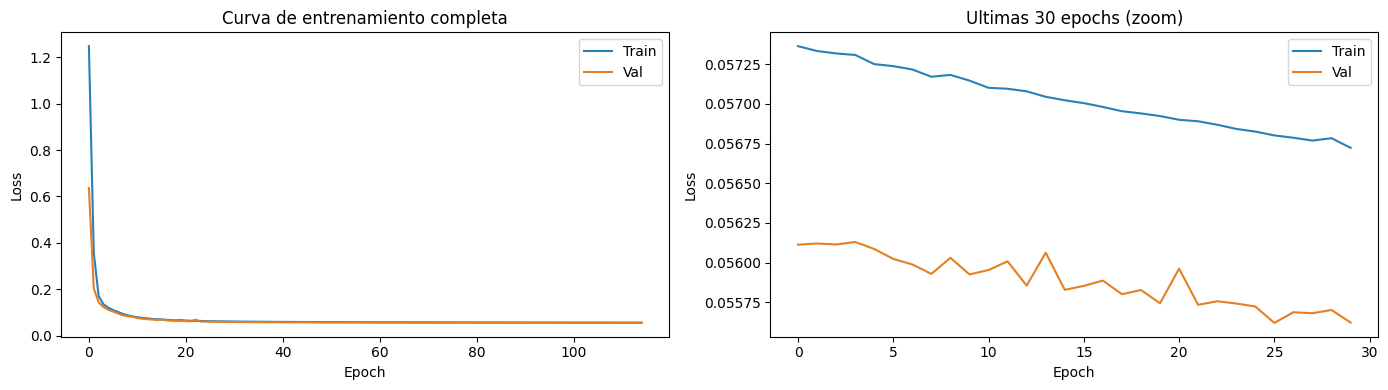

In [16]:
import matplotlib.pyplot as plt
import torch
from pathlib import Path

BACKBONE_PATH = Path('/kaggle/working/models/checkpoint.pt')

ckpt     = torch.load(BACKBONE_PATH, map_location='cpu', weights_only=False)
history  = ckpt['history']
best_val = ckpt['best_val']

print(f'Epochs completadas: {len(history["train"])}')
print(f'Mejor val loss:     {best_val:.6f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train'], label='Train', color='#2980b9', linewidth=1.5)
axes[0].plot(history['val'],   label='Val',   color='#e67e22', linewidth=1.5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Curva de entrenamiento completa')
axes[0].legend()

n_show = min(30, len(history['train']))
axes[1].plot(history['train'][-n_show:], label='Train', color='#2980b9', linewidth=1.5)
axes[1].plot(history['val'][-n_show:],   label='Val',   color='#e67e22', linewidth=1.5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title(f'Ultimas {n_show} epochs (zoom)')
axes[1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/models/training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 7 — Generar perfiles de las 4 maquinas

In [21]:
import torch
from pathlib import Path

ckpt = torch.load('/kaggle/working/models/checkpoint.pt', map_location='cpu', weights_only=False)
print("Claves disponibles en backbone.pt:")
for k, v in ckpt.items():
    if isinstance(v, dict):
        print(f"  {k}: dict con {len(v)} entradas")
    elif isinstance(v, list):
        print(f"  {k}: list con {len(v)} elementos")
    else:
        print(f"  {k}: {v}")

Claves disponibles en backbone.pt:
  epoch: 115
  model_state: dict con 90 entradas
  optimizer_state: dict con 2 entradas
  scheduler_state: dict con 11 entradas
  scaler_state: dict con 5 entradas
  best_val: 0.05562030773000859
  best_state: dict con 90 entradas
  patience_c: 4
  history: dict con 2 entradas
  global_mean: 0.0
  global_std: 1.0
  machine_counts: dict con 4 entradas
  embedding_dim: 32


In [24]:
import torch
from pathlib import Path
from model.backbone import AcousticBackbone

# Cargar checkpoint
ckpt = torch.load('/kaggle/working/models/checkpoint.pt', map_location='cpu', weights_only=False)

# Reconstruir el modelo y cargar el mejor estado
model = AcousticBackbone(embedding_dim=ckpt['embedding_dim'])
model.load_state_dict(ckpt['best_state'])
model.eval()

# Guardar en el formato correcto que esperan las celdas siguientes
torch.save({
    'encoder_state':  model.encoder.state_dict(),
    'backbone_state': model.state_dict(),
    'embedding_dim':  ckpt['embedding_dim'],
    'global_mean':    ckpt['global_mean'],
    'global_std':     ckpt['global_std'],
    'machine_counts': ckpt['machine_counts'],
    'history':        ckpt['history'],
    'best_val_loss':  ckpt['best_val'],
}, '/kaggle/working/models/checkpoint.pt')

print(f'backbone.pt regenerado correctamente')
print(f'  Embedding dim:  {ckpt["embedding_dim"]}')
print(f'  Mejor val loss: {ckpt["best_val"]:.6f}')
print(f'  Epochs totales: {ckpt["epoch"]}')

backbone.pt regenerado correctamente
  Embedding dim:  32
  Mejor val loss: 0.055620
  Epochs totales: 115


In [25]:
import numpy as np
import torch
from pathlib import Path
from model.backbone import ConvEncoder
from model.machine_profile import MachineProfile

PATCHES_DIR  = Path('/kaggle/input/datasets/sergiojimnez07/sonitel-code')
BACKBONE_PATH = Path('/kaggle/working/models/checkpoint.pt')
PROFILES_DIR  = Path('/kaggle/working/profiles')
PROFILES_DIR.mkdir(exist_ok=True)
MACHINES      = ['fan', 'pump', 'slider', 'valve']
DEVICE        = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE    = 1024

# Cargar encoder
ckpt = torch.load(BACKBONE_PATH, map_location=DEVICE, weights_only=False)
encoder = ConvEncoder(embedding_dim=ckpt['embedding_dim']).to(DEVICE)
encoder.load_state_dict(ckpt['encoder_state'])
encoder.eval()
for p in encoder.parameters():
    p.requires_grad = False

global_mean = ckpt['global_mean']
global_std  = ckpt['global_std']

print('Generando perfiles de maquinas...\n')

for machine in MACHINES:
    patches      = np.load(PATCHES_DIR / f'{machine}_train.npy')
    patches_norm = (patches - global_mean) / (global_std + 1e-8)

    embeddings = []
    for i in range(0, len(patches_norm), BATCH_SIZE):
        batch = torch.FloatTensor(patches_norm[i:i+BATCH_SIZE]).to(DEVICE)
        with torch.no_grad():
            embeddings.append(encoder(batch).cpu().numpy())
    embeddings = np.concatenate(embeddings, axis=0)

    profile = MachineProfile(machine_id=machine)
    profile.fit(embeddings, threshold_percentile=97.0)
    profile.save(str(PROFILES_DIR / f'{machine}.npz'))

    del patches, patches_norm, embeddings
    print(f'  {machine:8s} | umbral={profile.threshold_:.4f} | {profile.n_samples_:,} embeddings')

print(f'\nPerfiles guardados en {PROFILES_DIR}')

Generando perfiles de maquinas...

  fan      | umbral=11.8817 | 65,200 embeddings
  pump     | umbral=10.7943 | 59,984 embeddings
  slider   | umbral=10.4934 | 51,264 embeddings
  valve    | umbral=10.7091 | 59,056 embeddings

Perfiles guardados en /kaggle/working/profiles


## Celda 8 — Evaluar AUC-ROC

Evaluando AUC-ROC...

  fan      | AUC-ROC=0.6025 | F1=0.063 | Precision=0.331 | Recall=0.035
  pump     | AUC-ROC=0.6062 | F1=0.117 | Precision=0.256 | Recall=0.076
  slider   | AUC-ROC=0.8277 | F1=0.502 | Precision=0.807 | Recall=0.364
  valve    | AUC-ROC=0.4531 | F1=0.033 | Precision=0.093 | Recall=0.020

  Media AUC-ROC: 0.6224


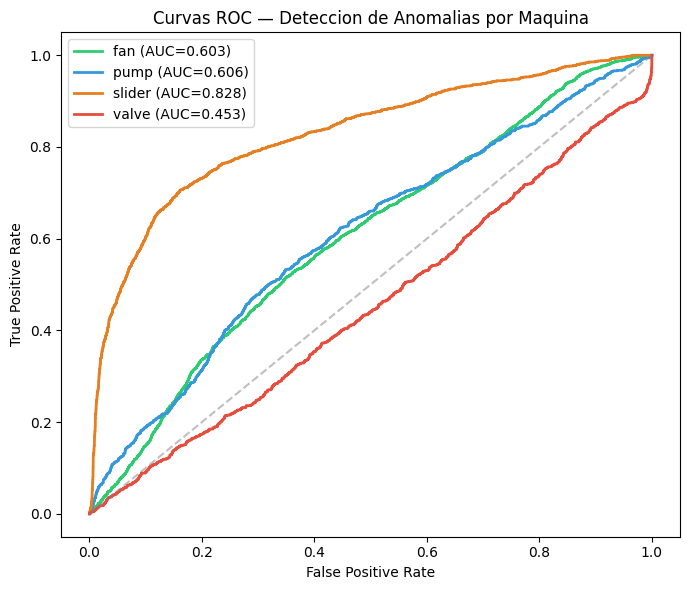

In [26]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
from model.machine_profile import MachineProfile
from model.backbone import ConvEncoder
from pathlib import Path

PATCHES_DIR  = Path('/kaggle/input/datasets/sergiojimnez07/sonitel-code')
BACKBONE_PATH = Path('/kaggle/working/models/checkpoint.pt')
PROFILES_DIR  = Path('/kaggle/working/profiles')
MACHINES      = ['fan', 'pump', 'slider', 'valve']
DEVICE        = 'cuda' if torch.cuda.is_available() else 'cpu'

# Cargar encoder
ckpt = torch.load(BACKBONE_PATH, map_location=DEVICE, weights_only=False)
encoder = ConvEncoder(embedding_dim=ckpt['embedding_dim']).to(DEVICE)
encoder.load_state_dict(ckpt['encoder_state'])
encoder.eval()
for p in encoder.parameters():
    p.requires_grad = False

global_mean = ckpt['global_mean']
global_std  = ckpt['global_std']

print('Evaluando AUC-ROC...\n')
all_results = {}

for machine in MACHINES:
    patches  = np.load(PATCHES_DIR / f'{machine}_test.npy')
    labels   = np.load(PATCHES_DIR / f'{machine}_test_labels.npy')
    ppf      = np.load(PATCHES_DIR / f'{machine}_test_patches_per_file.npy')
    profile  = MachineProfile.load(str(PROFILES_DIR / f'{machine}.npz'))

    patches_norm = (patches - global_mean) / (global_std + 1e-8)
    embeddings = []
    for i in range(0, len(patches_norm), 512):
        batch = torch.FloatTensor(patches_norm[i:i+512]).to(DEVICE)
        with torch.no_grad():
            embeddings.append(encoder(batch).cpu().numpy())
    embeddings = np.concatenate(embeddings, axis=0)

    distances   = profile.score_batch(embeddings)
    file_scores = []
    idx = 0
    for n in ppf:
        file_scores.append(float(np.mean(distances[idx:idx+int(n)])))
        idx += int(n)
    file_scores = np.array(file_scores[:len(labels)])

    auc    = roc_auc_score(labels, file_scores)
    y_pred = (file_scores > profile.threshold_).astype(int)
    report = classification_report(labels, y_pred,
                                   target_names=['normal', 'anomaly'],
                                   output_dict=True)
    fpr, tpr, _ = roc_curve(labels, file_scores)
    all_results[machine] = {'auc': auc, 'fpr': fpr, 'tpr': tpr}

    print(f'  {machine:8s} | AUC-ROC={auc:.4f} | '
          f'F1={report["anomaly"]["f1-score"]:.3f} | '
          f'Precision={report["anomaly"]["precision"]:.3f} | '
          f'Recall={report["anomaly"]["recall"]:.3f}')

print(f'\n  Media AUC-ROC: {np.mean([r["auc"] for r in all_results.values()]):.4f}')

# Curvas ROC
colors = {'fan': '#2ecc71', 'pump': '#3498db', 'slider': '#e67e22', 'valve': '#e74c3c'}
fig, ax = plt.subplots(figsize=(7, 6))
for machine, res in all_results.items():
    ax.plot(res['fpr'], res['tpr'],
            label=f"{machine} (AUC={res['auc']:.3f})",
            color=colors[machine], linewidth=2)
ax.plot([0,1],[0,1], '--', color='gray', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC — Deteccion de Anomalias por Maquina')
ax.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/models/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 9 — Ver ficheros para descargar

In [27]:
from pathlib import Path

print('Ficheros listos para descargar (panel Output):\n')
for f in sorted(Path('/kaggle/working').rglob('*')):
    if f.is_file() and f.suffix in ['.pt', '.npz', '.png']:
        size = f.stat().st_size / 1024
        unit = 'KB'
        if size > 1024:
            size /= 1024; unit = 'MB'
        print(f'  {str(f.relative_to("/kaggle/working")):45s} {size:6.1f} {unit}')

print('''
Descarga y pon en tu proyecto local:
  models/backbone.pt       -> sonitel_v2/models/backbone.pt
  profiles/fan.npz         -> sonitel_v2/profiles/fan.npz
  profiles/pump.npz        -> sonitel_v2/profiles/pump.npz
  profiles/slider.npz      -> sonitel_v2/profiles/slider.npz
  profiles/valve.npz       -> sonitel_v2/profiles/valve.npz

Despues lanza la app:
  streamlit run app_streamlit.py
''')

Ficheros listos para descargar (panel Output):

  models/backbone.pt                              17.6 MB
  models/checkpoint.pt                            17.6 MB
  models/roc_curves.png                          108.9 KB
  models/training_curve.png                       82.3 KB
  profiles/fan.npz                                 9.4 KB
  profiles/pump.npz                                9.4 KB
  profiles/slider.npz                              9.4 KB
  profiles/valve.npz                               9.4 KB

Descarga y pon en tu proyecto local:
  models/backbone.pt       -> sonitel_v2/models/backbone.pt
  profiles/fan.npz         -> sonitel_v2/profiles/fan.npz
  profiles/pump.npz        -> sonitel_v2/profiles/pump.npz
  profiles/slider.npz      -> sonitel_v2/profiles/slider.npz
  profiles/valve.npz       -> sonitel_v2/profiles/valve.npz

Despues lanza la app:
  streamlit run app_streamlit.py

